Doweload thư viện và hadoop

In [ ]:
!apt-get update
!apt-get install openjdk-11-jdk-headless -qq > /dev/null


!wget -q --show-progress https://dlcdn.apache.org/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz
!tar -xzf hadoop-3.3.6.tar.gz
!mv hadoop-3.3.6 /usr/local/hadoop


import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["HADOOP_HOME"] = "/usr/local/hadoop"
os.environ["PATH"] += ":/usr/local/hadoop/bin:/usr/local/hadoop/sbin"

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:6 https://cli.github.com/packages stable InRelease [3,917 B]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,135 kB]
Get:12 https://cli.github.com/packages stable/main amd64 Packages [343 B]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy

Kiểm tra hadoop version

In [ ]:
!hdfs version

Hadoop 3.3.6
Source code repository https://github.com/apache/hadoop.git -r 1be78238728da9266a4f88195058f08fd012bf9c
Compiled by ubuntu on 2023-06-18T08:22Z
Compiled on platform linux-x86_64
Compiled with protoc 3.7.1
From source with checksum 5652179ad55f76cb287d9c633bb53bbd
This command was run using /usr/local/hadoop/share/hadoop/common/hadoop-common-3.3.6.jar


upload csv

In [ ]:
from google.colab import files

uploaded = files.upload()  # 🔹 Chọn file CSV của bạn để tải lên

# In tên file đã upload
for filename in uploaded.keys():
    print(f" File '{filename}' đã được tải lên thành công!")

Saving Student Depression Dataset.csv to Student Depression Dataset.csv
 File 'Student Depression Dataset.csv' đã được tải lên thành công!


Đưa file csv vào hadoop


In [ ]:
!ls -lh

total 699M
-rw-r--r-- 1 root root 697M Jun 25  2023  hadoop-3.3.6.tar.gz
drwxr-xr-x 1 root root 4.0K Nov 12 14:30  sample_data
-rw-r--r-- 1 root root 2.7M Nov 14 01:26 'Student Depression Dataset.csv'


In [ ]:
!hdfs dfs -mkdir -p /user/colab/csv_data
!hdfs dfs -put -f /content/Student\ Depression\ Dataset.csv /user/colab/csv_data/
!hdfs dfs -ls /user/colab/csv_data

Found 1 items
-rw-r--r--   1 root root    2807716 2025-11-14 01:27 /user/colab/csv_data/Student Depression Dataset.csv


chạy file csv bằng hdfs giả lập

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("DepressionDataset") \
    .config("spark.hadoop.fs.defaultFS", "file:///") \
    .getOrCreate()

# Đọc file CSV local
df = spark.read.csv("file:///content/Student Depression Dataset.csv", header=True, inferSchema=True)

df.show()

+---+------+----+-------------+----------+-----------------+-------------+----+------------------+----------------+-----------------+--------------+--------+-------------------------------------+----------------+----------------+--------------------------------+----------+
| id|Gender| Age|         City|Profession|Academic Pressure|Work Pressure|CGPA|Study Satisfaction|Job Satisfaction|   Sleep Duration|Dietary Habits|  Degree|Have you ever had suicidal thoughts ?|Work/Study Hours|Financial Stress|Family History of Mental Illness|Depression|
+---+------+----+-------------+----------+-----------------+-------------+----+------------------+----------------+-----------------+--------------+--------+-------------------------------------+----------------+----------------+--------------------------------+----------+
|  2|  Male|33.0|Visakhapatnam|   Student|              5.0|          0.0|8.97|               2.0|             0.0|        5-6 hours|       Healthy| B.Pharm|                     

In [ ]:
from pyspark.sql import functions as F

numeric_cols = [c for c, t in df.dtypes if t in ('int', 'double', 'float')]
categorical_cols = [c for c, t in df.dtypes if t not in ('int', 'double', 'float')]

print("\n=== CÁC CỘT KIỂU SỐ ===")
for col in numeric_cols:
    print(f"- {col}")

print("\n=== CÁC CỘT KIỂU PHÂN LOẠI / NHỊ PHÂN ===")
for col in categorical_cols:
    print(f"- {col}")



=== CÁC CỘT KIỂU SỐ ===
- id
- Age
- Academic Pressure
- Work Pressure
- CGPA
- Study Satisfaction
- Job Satisfaction
- Work/Study Hours
- Financial Stress
- Depression

=== CÁC CỘT KIỂU PHÂN LOẠI / NHỊ PHÂN ===
- Gender
- City
- Profession
- Sleep Duration
- Dietary Habits
- Degree
- Have you ever had suicidal thoughts ?
- Family History of Mental Illness


In [ ]:
from pyspark.sql import functions as F
from pyspark.sql import Row

print("\n=== THỐNG KÊ CHO THUỘC TÍNH KIỂU SỐ ===")

numeric_summary_rows = []

for c in numeric_cols:
    stats = df.agg(
        F.mean(c).alias("Mean"),
        F.expr(f"percentile_approx(`{c}`, 0.5)").alias("Median"),
        ((F.min(c) + F.max(c)) / 2).alias("Midrange"),
        F.min(c).alias("Min"),
        F.max(c).alias("Max"),
        F.expr(f"percentile_approx(`{c}`, 0.25)").alias("Q1"),
        F.expr(f"percentile_approx(`{c}`, 0.75)").alias("Q3")
    ).collect()[0]

    numeric_summary_rows.append(
        Row(
            Thuộc_tính=str(c),
            Mean=float(stats["Mean"]) if stats["Mean"] is not None else None,
            Median=float(stats["Median"]) if stats["Median"] is not None else None,
            Midrange=float(stats["Midrange"]) if stats["Midrange"] is not None else None,
            Min=float(stats["Min"]) if stats["Min"] is not None else None,
            Max=float(stats["Max"]) if stats["Max"] is not None else None,
            Q1=float(stats["Q1"]) if stats["Q1"] is not None else None,
            Q3=float(stats["Q3"]) if stats["Q3"] is not None else None
        )
    )


numeric_summary_df = spark.createDataFrame(numeric_summary_rows)

numeric_summary_df.show(truncate=False)




=== THỐNG KÊ CHO THUỘC TÍNH KIỂU SỐ ===
+------------------+---------------------+-------+--------+----+--------+-------+--------+
|Thuộc_tính        |Mean                 |Median |Midrange|Min |Max     |Q1     |Q3      |
+------------------+---------------------+-------+--------+----+--------+-------+--------+
|id                |70442.1494211677     |70659.0|70350.5 |2.0 |140699.0|35031.0|105809.0|
|Age               |25.82230027597577    |25.0   |38.5    |18.0|59.0    |21.0   |30.0    |
|Academic Pressure |3.1412135765743163   |3.0    |2.5     |0.0 |5.0     |2.0    |4.0     |
|Work Pressure     |4.3009211139385684E-4|0.0    |2.5     |0.0 |5.0     |0.0    |0.0     |
|CGPA              |7.6561041718936975   |7.77   |5.0     |0.0 |10.0    |6.29   |8.92    |
|Study Satisfaction|2.943837138453819    |3.0    |2.5     |0.0 |5.0     |2.0    |4.0     |
|Job Satisfaction  |6.809791763736067E-4 |0.0    |2.0     |0.0 |4.0     |0.0    |0.0     |
|Work/Study Hours  |7.156983620658758    |8.0    

In [ ]:
print("\n=== THỐNG KÊ CHO THUỘC TÍNH PHÂN LOẠI / NHỊ PHÂN ===")

categorical_summary = []
total_count = df.count()

for c in categorical_cols:
    # Lấy giá trị duy nhất
    unique_vals = [r[c] for r in df.select(c).distinct().collect()]

    mode_row = (
        df.groupBy(c)
        .agg(F.count("*").alias("count"))
        .orderBy(F.desc("count"))
        .first()
    )
    mode_value = mode_row[c] if mode_row else None

    counts = (
        df.groupBy(c)
        .agg(F.count("*").alias("Tần suất"))
        .withColumn("Tỷ lệ (%)", (F.col("Tần suất") / total_count * 100).cast("double"))
        .orderBy(F.desc("Tần suất"))
    )

    freq_dict = {r[c]: r["Tần suất"] for r in counts.collect()}
    perc_dict = {r[c]: round(r["Tỷ lệ (%)"], 2) for r in counts.collect()}

    categorical_summary.append({
        "Thuộc tính": c,
        "Kiểu dữ liệu": "Rời rạc / Nhị phân",
        "Giá trị duy nhất": unique_vals,
        "Mode": mode_value,
        "Tần suất": freq_dict,
        "Tỷ lệ (%)": perc_dict
    })

from pyspark.sql import Row
cat_df = spark.createDataFrame([Row(**x) for x in categorical_summary])
cat_df.show(truncate=False)


=== THỐNG KÊ CHO THUỘC TÍNH PHÂN LOẠI / NHỊ PHÂN ===
+-------------------------------------+------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Tiền xử lý

In [ ]:
df.dtypes

[('id', 'int'),
 ('Gender', 'string'),
 ('Age', 'double'),
 ('City', 'string'),
 ('Profession', 'string'),
 ('Academic Pressure', 'double'),
 ('Work Pressure', 'double'),
 ('CGPA', 'double'),
 ('Study Satisfaction', 'double'),
 ('Job Satisfaction', 'double'),
 ('Sleep Duration', 'string'),
 ('Dietary Habits', 'string'),
 ('Degree', 'string'),
 ('Have you ever had suicidal thoughts ?', 'string'),
 ('Work/Study Hours', 'double'),
 ('Financial Stress', 'double'),
 ('Family History of Mental Illness', 'string'),
 ('Depression', 'int')]

In [ ]:
from pyspark.sql.functions import col, sum as spark_sum, when

null_count_df = df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
])

quoted_columns = [f"`{c}`" for c in df.columns]
total_nulls = null_count_df.selectExpr(" + ".join(quoted_columns)).collect()[0][0]
print(f"Tổng số giá trị null trong toàn bộ bảng: {total_nulls}")

Tổng số giá trị null trong toàn bộ bảng: 3


In [ ]:
unique_counts = {col: df.select(col).distinct().count() for col in df.columns}

for col, count in unique_counts.items():
    print(f" '{col}': {count} unique values")

 'id': 27901 unique values
 'Gender': 2 unique values
 'Age': 34 unique values
 'City': 52 unique values
 'Profession': 14 unique values
 'Academic Pressure': 6 unique values
 'Work Pressure': 3 unique values
 'CGPA': 332 unique values
 'Study Satisfaction': 6 unique values
 'Job Satisfaction': 5 unique values
 'Sleep Duration': 5 unique values
 'Dietary Habits': 4 unique values
 'Degree': 28 unique values
 'Have you ever had suicidal thoughts ?': 2 unique values
 'Work/Study Hours': 13 unique values
 'Financial Stress': 6 unique values
 'Family History of Mental Illness': 2 unique values
 'Depression': 2 unique values


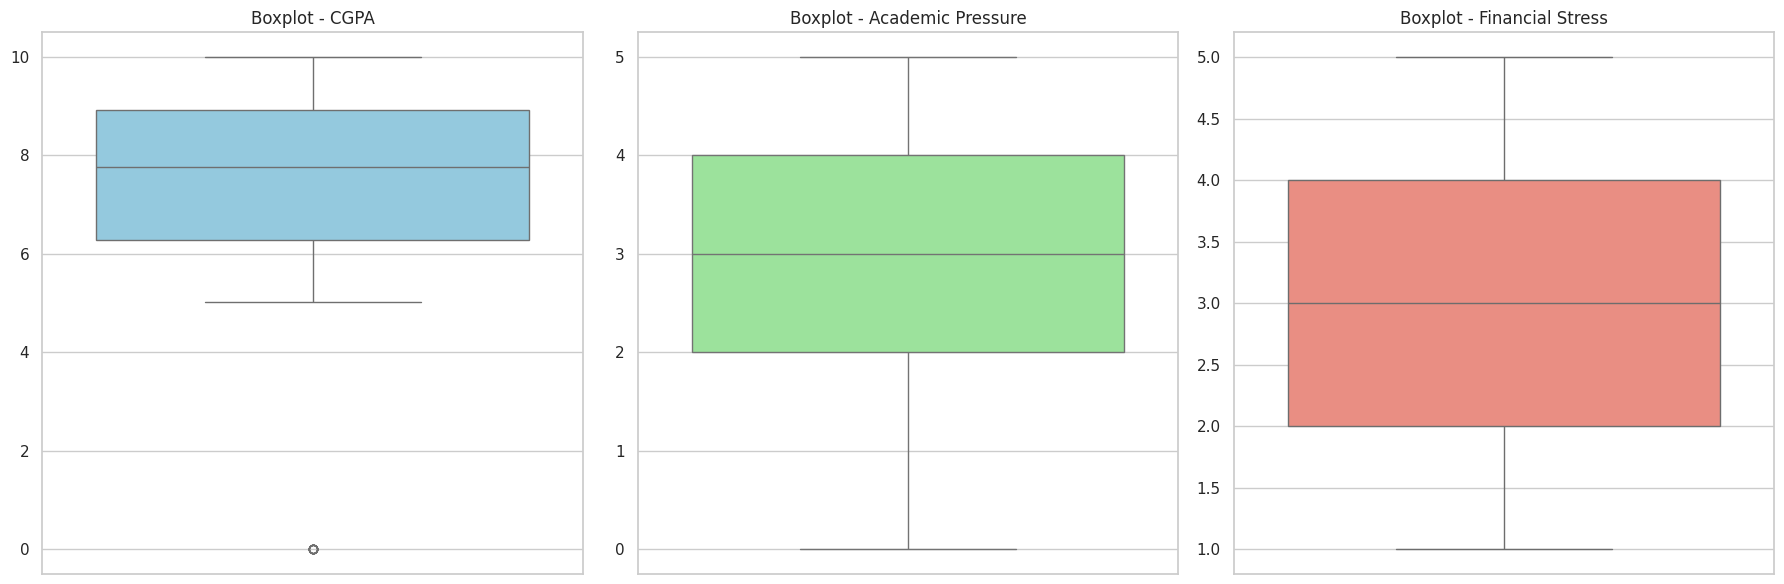

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

data = df.select("CGPA", "Academic Pressure", "Financial Stress") \
         .na.drop() \
         .collect()

cgpa = [row["CGPA"] for row in data]
academic_pressure = [row["Academic Pressure"] for row in data]
financial_stress = [row["Financial Stress"] for row in data]

sns.set(style="whitegrid")
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.boxplot(y=cgpa, color='skyblue')
plt.title('Boxplot - CGPA')

plt.subplot(1, 3, 2)
sns.boxplot(y=academic_pressure, color='lightgreen')
plt.title('Boxplot - Academic Pressure')

plt.subplot(1, 3, 3)
sns.boxplot(y=financial_stress, color='salmon')
plt.title('Boxplot - Financial Stress')

plt.tight_layout()
plt.show()


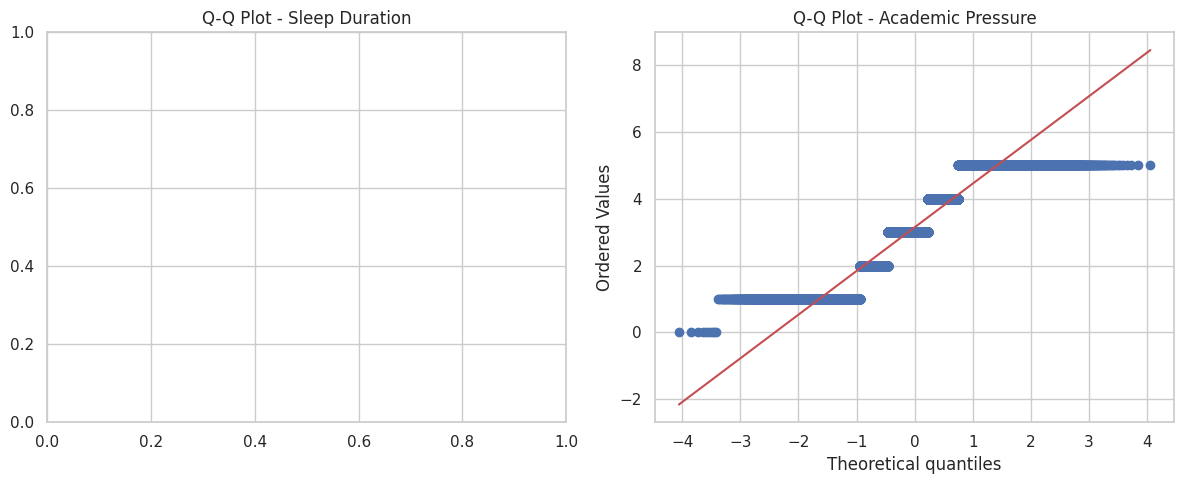

In [ ]:
from pyspark.sql.functions import col


df = df.withColumn("Sleep Duration", col("Sleep Duration").cast("double"))
df = df.withColumn("Academic Pressure", col("Academic Pressure").cast("double"))

sleep_duration_data = df.select("Sleep Duration").dropna().toPandas()
academic_pressure_data = df.select("Academic Pressure").dropna().toPandas()

import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
stats.probplot(sleep_duration_data['Sleep Duration'], dist="norm", plot=plt)
plt.title('Q-Q Plot - Sleep Duration')

plt.subplot(1, 2, 2)
stats.probplot(academic_pressure_data['Academic Pressure'], dist="norm", plot=plt)
plt.title('Q-Q Plot - Academic Pressure')

plt.tight_layout()
plt.show()

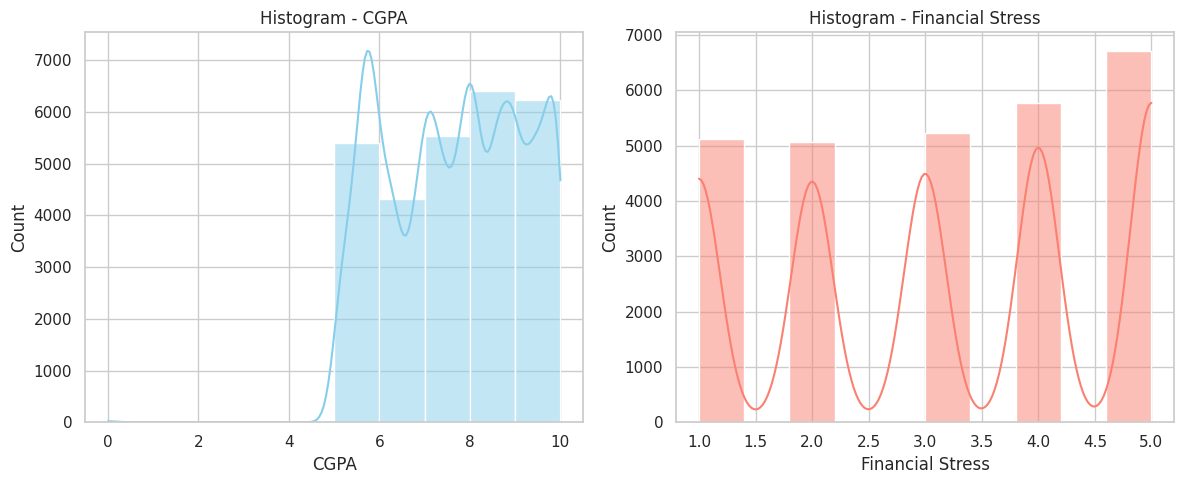

In [ ]:

df_selected = df.select("CGPA", "Financial Stress").na.drop()

pdf = df_selected.toPandas()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(pdf["CGPA"], kde=True, color="skyblue", bins=10)
plt.title("Histogram - CGPA")

plt.subplot(1, 2, 2)
sns.histplot(pdf["Financial Stress"], kde=True, color="salmon", bins=10)
plt.title("Histogram - Financial Stress")

plt.tight_layout()
plt.show()

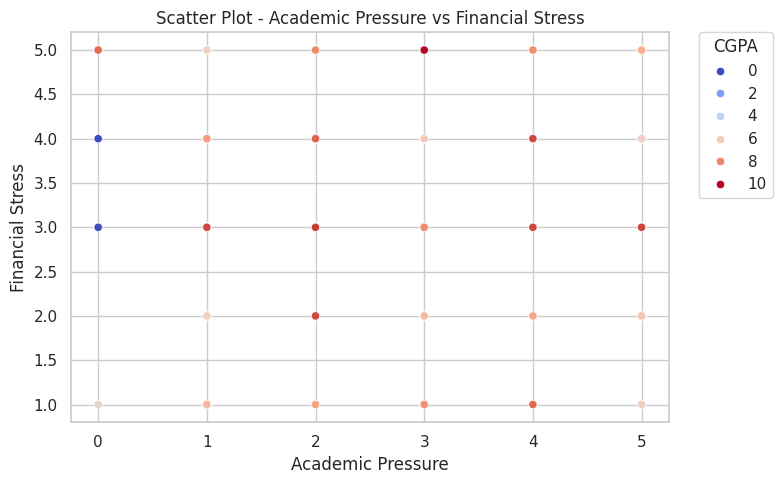

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chọn các cột cần thiết và loại bỏ giá trị null
df_selected = df.select("Academic Pressure", "Financial Stress", "CGPA").na.drop()

# Chuyển từ Spark DataFrame sang Pandas
pdf = df_selected.toPandas()

# ========== SCATTER PLOT ==========
plt.figure(figsize=(8, 5))
scatter = sns.scatterplot(
    data=pdf,
    x="Academic Pressure",
    y="Financial Stress",
    hue="CGPA",
    palette="coolwarm"
)
plt.title("Scatter Plot - Academic Pressure vs Financial Stress")

plt.legend(
    title="CGPA",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.
)

plt.tight_layout()
plt.show()



/tmp/ipython-input-2009996973.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdf, x="City", y="CGPA", palette="Set2")


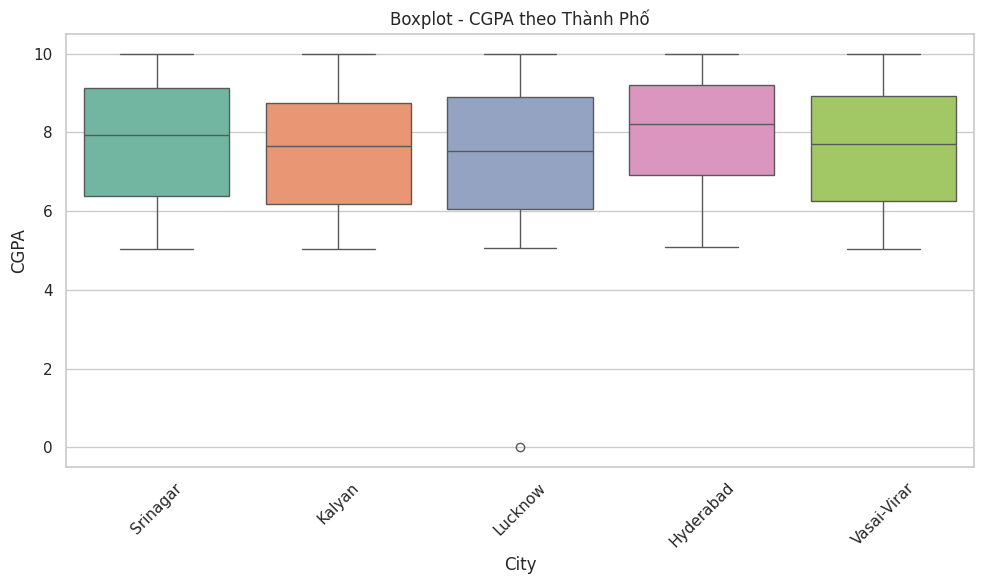

In [ ]:
from pyspark.sql import functions as F
import seaborn as sns
import matplotlib.pyplot as plt

df_grouped = df.select("City", "CGPA", "Academic Pressure").na.drop()

top_cities = (
    df_grouped.groupBy("City")
    .count()
    .orderBy(F.desc("count"))
    .limit(5)
    .select("City")
    .rdd.flatMap(lambda x: x)
    .collect()
)
df_top = df_grouped.filter(F.col("City").isin(top_cities))

pdf = df_top.toPandas()

plt.figure(figsize=(10, 6))
sns.boxplot(data=pdf, x="City", y="CGPA", palette="Set2")
plt.title("Boxplot - CGPA theo Thành Phố")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


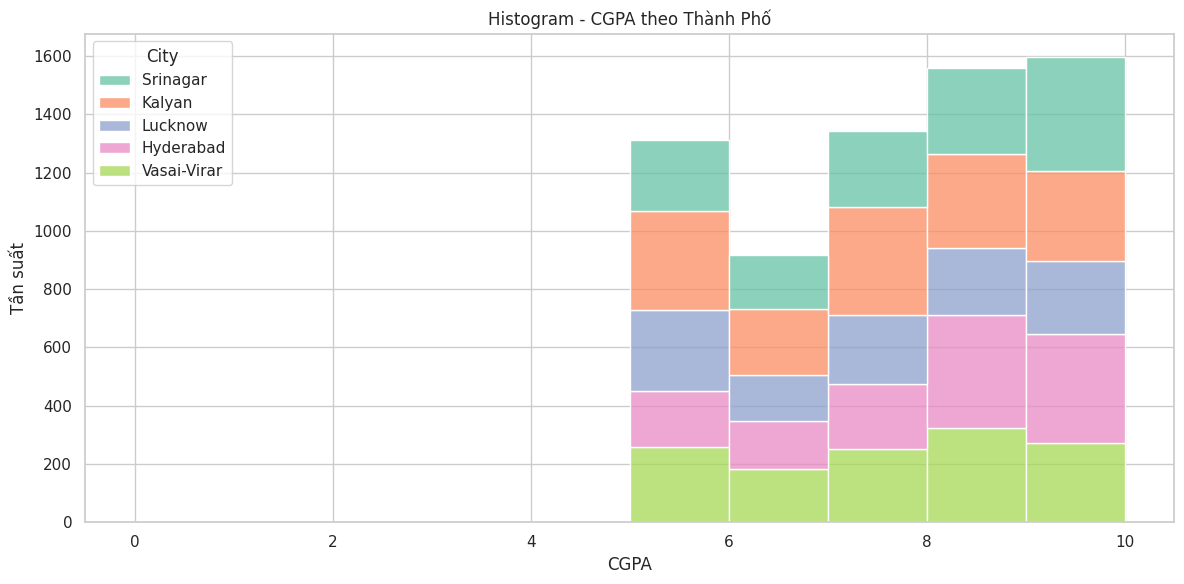

In [ ]:
from pyspark.sql import functions as F
import seaborn as sns
import matplotlib.pyplot as plt

df_grouped = df.select("City", "CGPA").na.drop()

top_cities = (
    df_grouped.groupBy("City")
    .count()
    .orderBy(F.desc("count"))
    .limit(5)
    .select("City")
    .rdd.flatMap(lambda x: x)
    .collect()
)

df_top = df_grouped.filter(F.col("City").isin(top_cities))

pdf = df_top.toPandas()

plt.figure(figsize=(12, 6))
sns.histplot(
    data=pdf,
    x="CGPA",
    hue="City",
    multiple="stack",
    palette="Set2",
    bins=10
)
plt.title("Histogram - CGPA theo Thành Phố")
plt.xlabel("CGPA")
plt.ylabel("Tần suất")
plt.tight_layout()
plt.show()



Các cột trong DataFrame:
['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']
Dữ liệu sau mã hóa:
    Gender   Age  CGPA  Degree
0       1  33.0  8.97       0
1       0  24.0  5.90       3
2       1  31.0  7.03       1
3       0  28.0  5.59       2

=== Ma trận tương quan ===
           Gender       Age      CGPA    Degree
Gender  1.000000  0.884652  0.851406 -0.894427
Age     0.884652  1.000000  0.826680 -0.989071
CGPA    0.851406  0.826680  1.000000 -0.899134
Degree -0.894427 -0.989071 -0.899134  1.000000


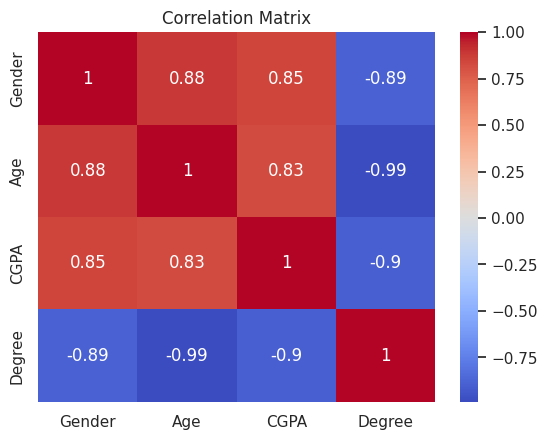

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

df = df.toPandas()
print("Các cột trong DataFrame:")
print(df.columns.tolist())
selected_columns = ['Gender', 'Age', 'CGPA', 'Degree']
df_selected = df[selected_columns].head(4).copy()
le = LabelEncoder()
for col in df_selected.columns:
    if df_selected[col].dtype == 'object':
        df_selected[col] = le.fit_transform(df_selected[col])

print("Dữ liệu sau mã hóa:\n", df_selected)
corr_matrix = df_selected.corr()
print("\n=== Ma trận tương quan ===\n", corr_matrix)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()




=== Độ đo Cosine (Cosine Similarity) giữa các dòng ===
           0         1         2         3
0  1.000000  0.991995  0.998606  0.994801
1  0.991995  1.000000  0.995358  0.997748
2  0.998606  0.995358  1.000000  0.998430
3  0.994801  0.997748  0.998430  1.000000


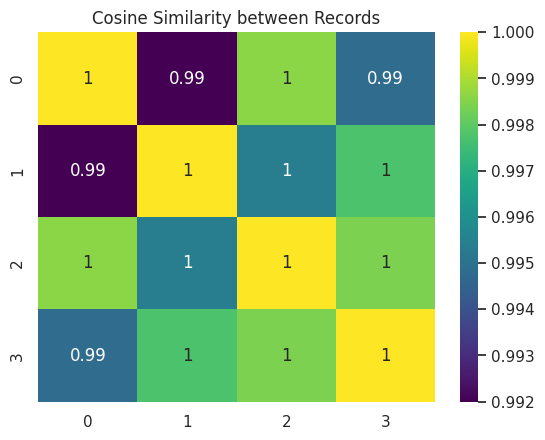

In [ ]:
cos_sim = cosine_similarity(df_selected)
cos_sim_df = pd.DataFrame(cos_sim, index=df_selected.index, columns=df_selected.index)
print("\n=== Độ đo Cosine (Cosine Similarity) giữa các dòng ===\n", cos_sim_df)


sns.heatmap(cos_sim_df, annot=True, cmap='viridis')
plt.title("Cosine Similarity between Records")
plt.show()

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("DepressionDataset") \
    .config("spark.hadoop.fs.defaultFS", "file:///") \
    .getOrCreate()

# Đọc file CSV local
df = spark.read.csv("file:///content/Student Depression Dataset.csv", header=True, inferSchema=True)

df.show()


+---+------+----+-------------+----------+-----------------+-------------+----+------------------+----------------+-----------------+--------------+--------+-------------------------------------+----------------+----------------+--------------------------------+----------+
| id|Gender| Age|         City|Profession|Academic Pressure|Work Pressure|CGPA|Study Satisfaction|Job Satisfaction|   Sleep Duration|Dietary Habits|  Degree|Have you ever had suicidal thoughts ?|Work/Study Hours|Financial Stress|Family History of Mental Illness|Depression|
+---+------+----+-------------+----------+-----------------+-------------+----+------------------+----------------+-----------------+--------------+--------+-------------------------------------+----------------+----------------+--------------------------------+----------+
|  2|  Male|33.0|Visakhapatnam|   Student|              5.0|          0.0|8.97|               2.0|             0.0|        5-6 hours|       Healthy| B.Pharm|                     

In [ ]:

df = df.fillna(0)
df

DataFrame[id: int, Gender: string, Age: double, City: string, Profession: string, Academic Pressure: double, Work Pressure: double, CGPA: double, Study Satisfaction: double, Job Satisfaction: double, Sleep Duration: string, Dietary Habits: string, Degree: string, Have you ever had suicidal thoughts ?: string, Work/Study Hours: double, Financial Stress: double, Family History of Mental Illness: string, Depression: int]

In [ ]:
print('số lượng hàng có trong df:', df.count())
print('số lượng cột có trong df:', len(df.columns))

số lượng hàng có trong df: 27901
số lượng cột có trong df: 18


In [ ]:
for i, col in enumerate(df.columns):
  print(f'Cột {i + 1}', col)

Cột 1 id
Cột 2 Gender
Cột 3 Age
Cột 4 City
Cột 5 Profession
Cột 6 Academic Pressure
Cột 7 Work Pressure
Cột 8 CGPA
Cột 9 Study Satisfaction
Cột 10 Job Satisfaction
Cột 11 Sleep Duration
Cột 12 Dietary Habits
Cột 13 Degree
Cột 14 Have you ever had suicidal thoughts ?
Cột 15 Work/Study Hours
Cột 16 Financial Stress
Cột 17 Family History of Mental Illness
Cột 18 Depression


In [ ]:
df.select('Age', 'CGPA').show(10)

+----+----+
| Age|CGPA|
+----+----+
|33.0|8.97|
|24.0| 5.9|
|31.0|7.03|
|28.0|5.59|
|25.0|8.13|
|29.0| 5.7|
|30.0|9.54|
|30.0|8.04|
|28.0|9.79|
|31.0|8.38|
+----+----+
only showing top 10 rows



In [ ]:
from pyspark.sql.functions import desc

df = df.orderBy(desc('CGPA'))
df.show()

+-----+------+----+---------+----------+-----------------+-------------+----+------------------+----------------+-----------------+--------------+--------+-------------------------------------+----------------+----------------+--------------------------------+----------+
|   id|Gender| Age|     City|Profession|Academic Pressure|Work Pressure|CGPA|Study Satisfaction|Job Satisfaction|   Sleep Duration|Dietary Habits|  Degree|Have you ever had suicidal thoughts ?|Work/Study Hours|Financial Stress|Family History of Mental Illness|Depression|
+-----+------+----+---------+----------+-----------------+-------------+----+------------------+----------------+-----------------+--------------+--------+-------------------------------------+----------------+----------------+--------------------------------+----------+
|24975|Female|31.0|  Chennai|   Student|              3.0|          0.0|10.0|               5.0|             0.0|        5-6 hours|      Moderate|    M.Ed|                             

In [ ]:
from pyspark.sql.functions import desc, col

df_sorted = df.orderBy(col("CGPA").desc())
df_sorted.show()

+-----+------+----+---------+----------+-----------------+-------------+----+------------------+----------------+-----------------+--------------+--------+-------------------------------------+----------------+----------------+--------------------------------+----------+
|   id|Gender| Age|     City|Profession|Academic Pressure|Work Pressure|CGPA|Study Satisfaction|Job Satisfaction|   Sleep Duration|Dietary Habits|  Degree|Have you ever had suicidal thoughts ?|Work/Study Hours|Financial Stress|Family History of Mental Illness|Depression|
+-----+------+----+---------+----------+-----------------+-------------+----+------------------+----------------+-----------------+--------------+--------+-------------------------------------+----------------+----------------+--------------------------------+----------+
|24975|Female|31.0|  Chennai|   Student|              3.0|          0.0|10.0|               5.0|             0.0|        5-6 hours|      Moderate|    M.Ed|                             

2.3

In [ ]:
num_rows = df.count()
num_cols = len(df.columns)

print(f"Kích thước dữ liệu: {num_rows} dòng × {num_cols} cột")

Kích thước dữ liệu: 27901 dòng × 18 cột


In [ ]:
print("\n Thống kê mô tả cho các biến số:")
df.describe().show(truncate=False)
from pyspark.sql import functions as F
from pyspark.sql import DataFrame


 Thống kê mô tả cho các biến số:
+-------+-----------------+------+------------------+-------------+--------------+------------------+---------------------+------------------+------------------+--------------------+--------------+--------------+------+-------------------------------------+-----------------+------------------+--------------------------------+------------------+
|summary|id               |Gender|Age               |City         |Profession    |Academic Pressure |Work Pressure        |CGPA              |Study Satisfaction|Job Satisfaction    |Sleep Duration|Dietary Habits|Degree|Have you ever had suicidal thoughts ?|Work/Study Hours |Financial Stress  |Family History of Mental Illness|Depression        |
+-------+-----------------+------+------------------+-------------+--------------+------------------+---------------------+------------------+------------------+--------------------+--------------+--------------+------+-------------------------------------+---------------

In [ ]:
print("\n Thống kê tần suất cho các biến phân loại:\n")

categorical_cols = [col_name for col_name, dtype in df.dtypes if dtype == "string"]

summary_tables = []

for col_name in categorical_cols:
    temp = (
        df.groupBy(col_name)
        .count()
        .withColumn("Column", F.lit(col_name))
        .withColumnRenamed(col_name, "Category")
    )
    summary_tables.append(temp)

final_summary = summary_tables[0]
for t in summary_tables[1:]:
    final_summary = final_summary.union(t)

final_summary = final_summary.orderBy("Column", F.desc("count"))

final_summary.show(truncate=False)



 Thống kê tần suất cho các biến phân loại:

+-------------+-----+------+
|Category     |count|Column|
+-------------+-----+------+
|Kalyan       |1570 |City  |
|Srinagar     |1372 |City  |
|Hyderabad    |1340 |City  |
|Vasai-Virar  |1290 |City  |
|Lucknow      |1155 |City  |
|Thane        |1139 |City  |
|Ludhiana     |1111 |City  |
|Agra         |1094 |City  |
|Surat        |1078 |City  |
|Kolkata      |1066 |City  |
|Jaipur       |1036 |City  |
|Patna        |1007 |City  |
|Visakhapatnam|969  |City  |
|Pune         |968  |City  |
|Ahmedabad    |951  |City  |
|Bhopal       |934  |City  |
|Chennai      |885  |City  |
|Meerut       |825  |City  |
|Rajkot       |816  |City  |
|Delhi        |768  |City  |
+-------------+-----+------+
only showing top 20 rows



In [ ]:
from pyspark.sql import functions as F

print("\n=== BẢNG TRUNG BÌNH THEO GIỚI TÍNH ===")

numeric_cols = [c for c, t in df.dtypes if t in ("int", "double", "float")]

gender_avg = df.groupBy("Gender").agg(
    *[F.mean(c).alias(f"avg_{c.replace(' ', '_').replace('/', '_')}") for c in numeric_cols]
)

stack_expr = ", ".join([f"'{c.replace(' ', '_').replace('/', '_')}', avg_{c.replace(' ', '_').replace('/', '_')}" for c in numeric_cols])


gender_avg_vertical = gender_avg.select(
    "Gender",
    F.expr(f"stack({len(numeric_cols)}, {stack_expr}) as (Attribute, Value)") # Changed aliases to ASCII
)

gender_avg_vertical.orderBy("Gender").show(100, truncate=False)


=== BẢNG TRUNG BÌNH THEO GIỚI TÍNH ===
+------+------------------+---------------------+
|Gender|Attribute         |Value                |
+------+------------------+---------------------+
|Female|id                |70660.3113161729     |
|Female|Age               |25.77238141492634    |
|Female|Academic_Pressure |3.1756516108143114   |
|Female|Work_Pressure     |0.0                  |
|Female|CGPA              |7.596644811397316    |
|Female|Study_Satisfaction|2.9679456046624577   |
|Female|Job_Satisfaction  |3.2378177108628785E-4|
|Female|Work_Study_Hours  |7.102881657762668    |
|Female|Financial_Stress  |3.1482111057147484   |
|Female|Depression        |0.5845070422535211   |
|Male  |id                |70268.79301472953    |
|Male  |Age               |25.861966938959284   |
|Male  |Academic_Pressure |3.1138483308676914   |
|Male  |Work_Pressure     |7.718530906284171E-4 |
|Male  |CGPA              |7.7033519328492535   |
|Male  |Study_Satisfaction|2.9246800025728437   |
|Male  |Jo

In [ ]:
from pyspark.sql import functions as F

print("\n TRUNG BÌNH THEO TÌNH TRẠNG TRẦM CẢM \n")
numeric_cols = [c for c, t in df.dtypes if t in ("int", "double", "float")]
dg = df.groupBy("Depression").agg(
    *[F.mean(c).alias(f"avg_{c}") for c in numeric_cols]
)

exprs = F.array(
    *[
        F.struct(F.lit(c).alias("Thuộc_tính"), F.col(c).alias("Giá_trị"))
        for c in dg.columns if c != "Depression"
    ]
)

dg_long = dg.select("Depression", F.explode(exprs).alias("g"))
dg_long = dg_long.select("Depression", "g.Thuộc_tính", "g.Giá_trị")
dg_long.orderBy("Depression").show(truncate=False)



 TRUNG BÌNH THEO TÌNH TRẠNG TRẦM CẢM 

+----------+----------------------+--------------------+
|Depression|Thuộc_tính            |Giá_trị             |
+----------+----------------------+--------------------+
|0         |avg_id                |70397.56108949416   |
|0         |avg_Age               |27.142412451361867  |
|0         |avg_Academic Pressure |2.361608300907912   |
|0         |avg_Work Pressure     |6.052745352356247E-4|
|0         |avg_CGPA              |7.6172823173369215  |
|0         |avg_Study Satisfaction|3.2155642023346305  |
|0         |avg_Job Satisfaction  |8.646779074794639E-4|
|0         |avg_Work/Study Hours  |6.2379593601383485  |
|0         |avg_Financial Stress  |2.5182879377431906  |
|0         |avg_Depression        |0.0                 |
|1         |avg_id                |70473.71553623897   |
|1         |avg_Age               |24.88773261508325   |
|1         |avg_Academic Pressure |3.693131733594515   |
|1         |avg_Work Pressure     |3.06072477962

In [ ]:
from pyspark.sql import functions as F

dg = df.groupBy("Depression").agg(
    *[F.mean(c).alias(f"avg_{c}") for c, t in df.dtypes if t in ["int", "double", "float"]]
)

print("=== TRUNG BÌNH THEO MỨC ĐỘ TRẦM CẢM  ===")

exprs = F.array(
    *[
        F.struct(F.lit(c).alias("Thuộc_tính"), F.col(c).alias("Giá_trị"))
        for c in dg.columns if c != "Depression"
    ]
)

dg_long = dg.select("Depression", F.explode(exprs).alias("g"))
dg_long = dg_long.select(
    "Depression",
    F.col("g.Thuộc_tính").alias("Thuộc_tính"),
    F.col("g.Giá_trị").alias("Giá_trị")
)

dg_long.orderBy("Depression").show(truncate=False)


=== TRUNG BÌNH THEO MỨC ĐỘ TRẦM CẢM  ===
+----------+----------------------+--------------------+
|Depression|Thuộc_tính            |Giá_trị             |
+----------+----------------------+--------------------+
|0         |avg_id                |70397.56108949416   |
|0         |avg_Age               |27.142412451361867  |
|0         |avg_Academic Pressure |2.361608300907912   |
|0         |avg_Work Pressure     |6.052745352356247E-4|
|0         |avg_CGPA              |7.6172823173369215  |
|0         |avg_Study Satisfaction|3.2155642023346305  |
|0         |avg_Job Satisfaction  |8.646779074794639E-4|
|0         |avg_Work/Study Hours  |6.2379593601383485  |
|0         |avg_Financial Stress  |2.5182879377431906  |
|0         |avg_Depression        |0.0                 |
|1         |avg_id                |70473.71553623897   |
|1         |avg_Age               |24.88773261508325   |
|1         |avg_Academic Pressure |3.693131733594515   |
|1         |avg_Work Pressure     |3.0607247796

In [ ]:
from pyspark.sql import functions as F

top_cities = (
    df.groupBy("City")
    .count()
    .orderBy(F.desc("count"))
    .limit(5)
)



df_top_cities = df.join(top_cities.select("City"), on="City", how="inner")

city_stats = (
    df_top_cities.groupBy("City")
    .agg(
        F.mean("CGPA").alias("Avg_CGPA"),
        F.mean("Academic Pressure").alias("Avg_AcademicPressure")
    )
    .orderBy(F.desc("Avg_CGPA"))
)

print("===  Trung bình CGPA & Academic Pressure theo thành phố ===")
city_stats.show(truncate=False)

exprs = F.array(
    F.struct(F.lit("Avg_CGPA").alias("Thuộc_tính"), F.col("Avg_CGPA").alias("Giá_trị")),
    F.struct(F.lit("Avg_AcademicPressure").alias("Thuộc_tính"), F.col("Avg_AcademicPressure").alias("Giá_trị"))
)

city_stats_long = city_stats.select("City", F.explode(exprs).alias("pair"))
city_stats_long = city_stats_long.select(
    "City",
    F.col("pair.Thuộc_tính"),
    F.col("pair.Giá_trị")
)


===  Trung bình CGPA & Academic Pressure theo thành phố ===
+-----------+------------------+--------------------+
|City       |Avg_CGPA          |Avg_AcademicPressure|
+-----------+------------------+--------------------+
|Hyderabad  |7.952477611940297 |3.2940298507462686  |
|Srinagar   |7.8121592565597515|3.057580174927114   |
|Vasai-Virar|7.6108139534883685|3.2077519379844963  |
|Lucknow    |7.561099567099561 |3.1636363636363636  |
|Kalyan     |7.561070063694261 |3.0847133757961784  |
+-----------+------------------+--------------------+



In [ ]:
print("===  Top 5 thành phố có nhiều sinh viên nhất ===")
top_cities.show()


print("=== Trung bình theo từng thuộc tính ===")
city_stats_long.show(truncate=False)

===  Top 5 thành phố có nhiều sinh viên nhất ===
+-----------+-----+
|       City|count|
+-----------+-----+
|     Kalyan| 1570|
|   Srinagar| 1372|
|  Hyderabad| 1340|
|Vasai-Virar| 1290|
|    Lucknow| 1155|
+-----------+-----+

=== Trung bình theo từng thuộc tính ===
+-----------+--------------------+------------------+
|City       |Thuộc_tính          |Giá_trị           |
+-----------+--------------------+------------------+
|Hyderabad  |Avg_CGPA            |7.952477611940297 |
|Hyderabad  |Avg_AcademicPressure|3.2940298507462686|
|Srinagar   |Avg_CGPA            |7.8121592565597515|
|Srinagar   |Avg_AcademicPressure|3.057580174927114 |
|Vasai-Virar|Avg_CGPA            |7.6108139534883685|
|Vasai-Virar|Avg_AcademicPressure|3.2077519379844963|
|Lucknow    |Avg_CGPA            |7.561099567099561 |
|Lucknow    |Avg_AcademicPressure|3.1636363636363636|
|Kalyan     |Avg_CGPA            |7.561070063694261 |
|Kalyan     |Avg_AcademicPressure|3.0847133757961784|
+-----------+---------------

In [ ]:
from pyspark.sql import functions as F

top_cities = (
    df.groupBy("City")
    .count()
    .orderBy(F.desc("count"))
    .limit(5)
)

print("===  Top 5 thành phố có nhiều sinh viên nhất ===")
top_cities.show()

df_top_cities = df.join(top_cities.select("City"), on="City", how="inner")

city_stats = (
    df_top_cities.groupBy("City")
    .agg(
        F.mean("CGPA").alias("Avg_CGPA"),
        F.mean("Academic Pressure").alias("Avg_AcademicPressure")
    )
    .orderBy(F.desc("Avg_CGPA"))
)

print("=== Trung bình theo từng thuộc tính ===")

===  Top 5 thành phố có nhiều sinh viên nhất ===
+-----------+-----+
|       City|count|
+-----------+-----+
|     Kalyan| 1570|
|   Srinagar| 1372|
|  Hyderabad| 1340|
|Vasai-Virar| 1290|
|    Lucknow| 1155|
+-----------+-----+

=== Trung bình theo từng thuộc tính ===


In [ ]:
from pyspark.sql import functions as F

print("\n===  Tỷ lệ trầm cảm theo giới tính  ===")
cross_tab = df.crosstab("Gender", "Depression")
cols = cross_tab.columns
total_col = F.expr(" + ".join([f"`{c}`" for c in cols if c != "Gender_Depression"]))
cross_tab = cross_tab.withColumn("Total", total_col)

for c in cols:
    if c != "Gender_Depression":
        cross_tab = cross_tab.withColumn(f"{c}_percent", F.col(c) / F.col("Total"))

cross_tab.select("Gender_Depression", *[c for c in cross_tab.columns if "percent" in c]).show(truncate=False)


===  Tỷ lệ trầm cảm theo giới tính  ===
+-----------------+-------------------+------------------+
|Gender_Depression|0_percent          |1_percent         |
+-----------------+-------------------+------------------+
|Female           |0.4154929577464789 |0.5845070422535211|
|Male             |0.41371325657683156|0.5862867434231684|
+-----------------+-------------------+------------------+



2.4

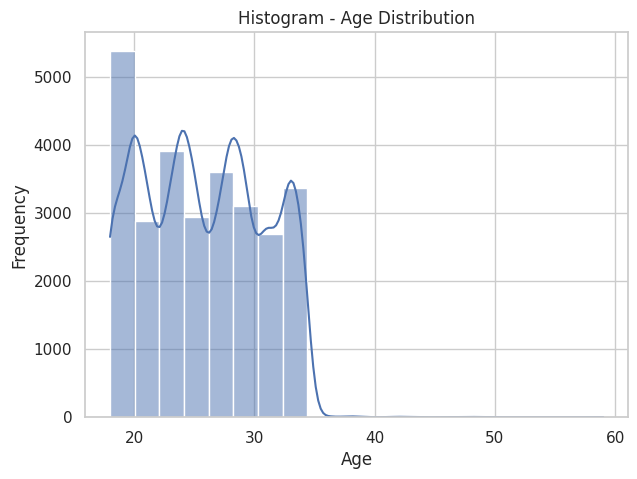

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

pdf = df.select("Age").dropna().toPandas()

sns.set(style="whitegrid")
plt.figure(figsize=(7, 5))
sns.histplot(data=pdf, x='Age', bins=20, kde=True)
plt.title('Histogram - Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()



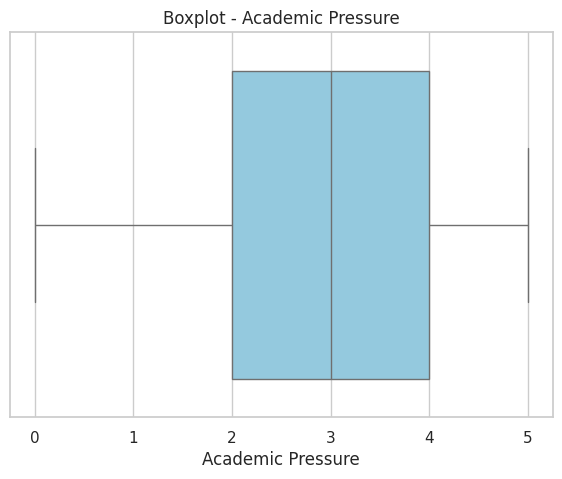

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

pdf = df.select("Academic Pressure").dropna().toPandas()

plt.figure(figsize=(7, 5))
sns.boxplot(data=pdf, x='Academic Pressure', color='skyblue')
plt.title('Boxplot - Academic Pressure')
plt.xlabel('Academic Pressure')
plt.show()


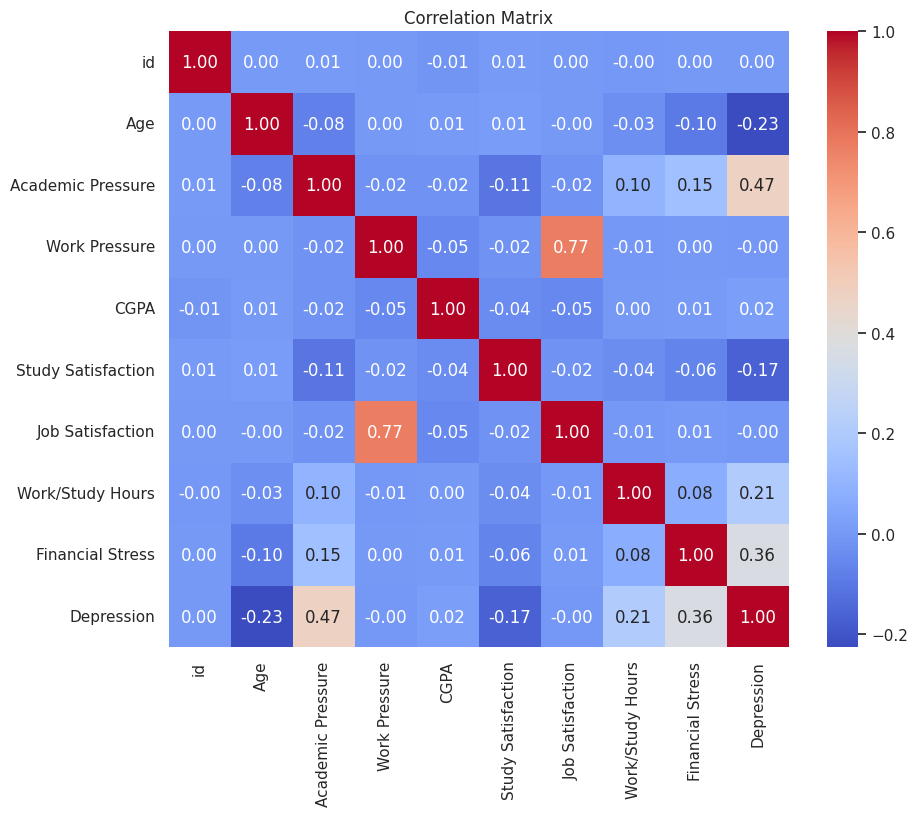

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

numeric_cols = [c for c, t in df.dtypes if t in ('int', 'double', 'float')]

pdf = df.select(*numeric_cols).dropna().toPandas()

plt.figure(figsize=(10, 8))
sns.heatmap(pdf.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


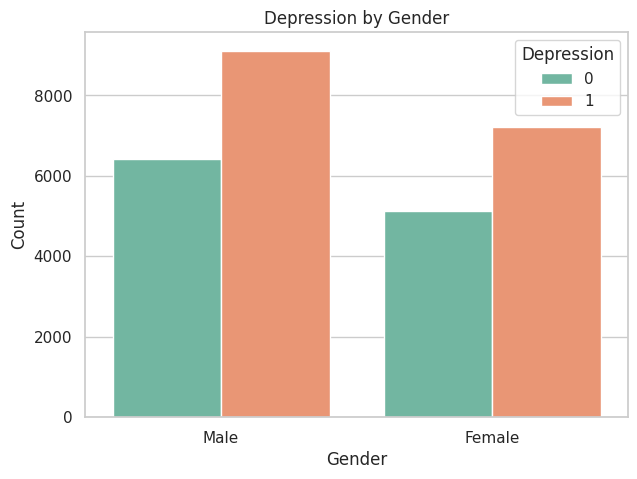

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

pdf = df.select("Gender", "Depression").dropna().toPandas()

plt.figure(figsize=(7, 5))
sns.countplot(data=pdf, x='Gender', hue='Depression', palette='Set2')
plt.title('Depression by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Depression')
plt.show()


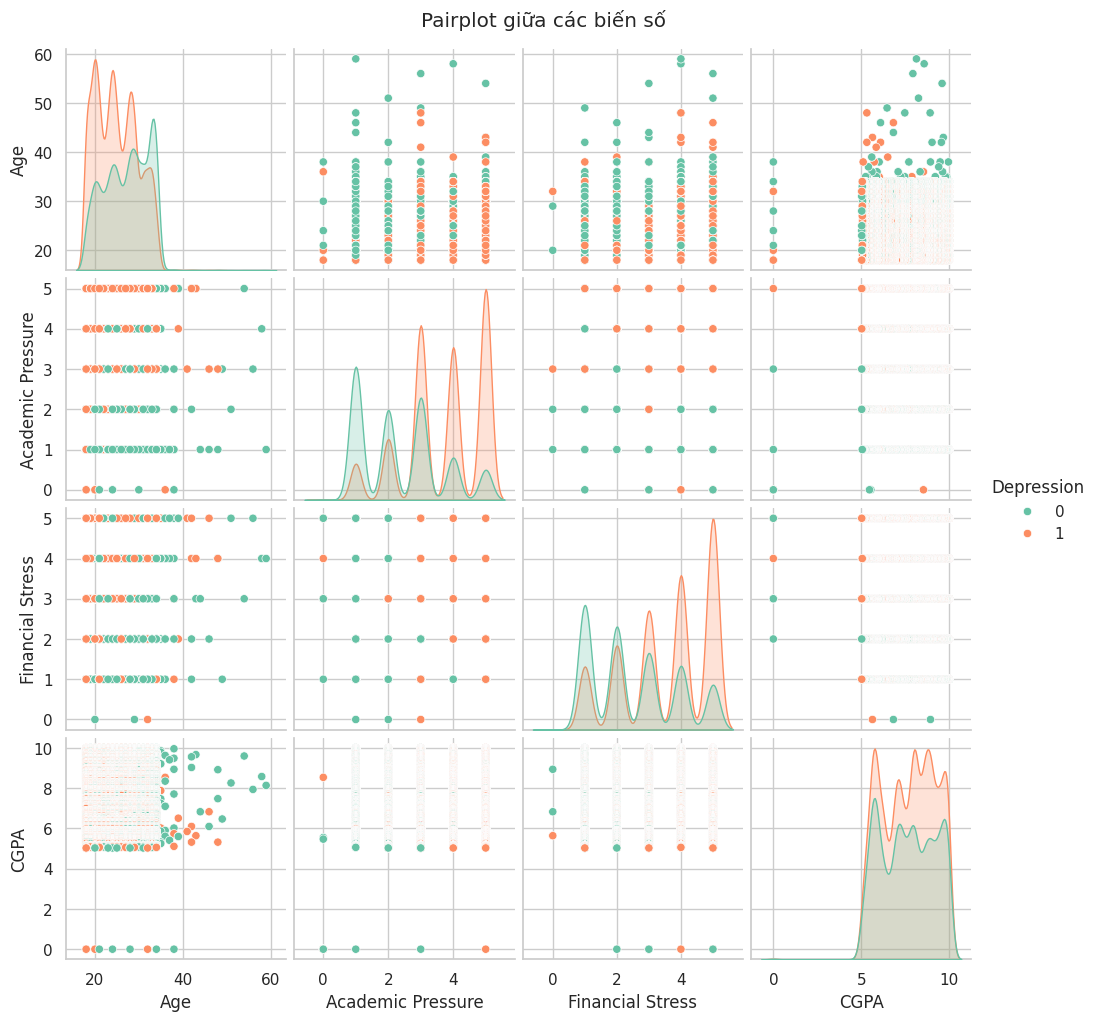

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pdf = df.select("Age", "Academic Pressure", "Financial Stress", "CGPA", "Depression") \
        .dropna() \
        .toPandas()

numeric_cols = ['Age', 'Academic Pressure', 'Financial Stress', 'CGPA']

sns.pairplot(pdf[numeric_cols + ['Depression']], hue='Depression', diag_kind='kde', palette='Set2')
plt.suptitle('Pairplot giữa các biến số', y=1.02)
plt.show()


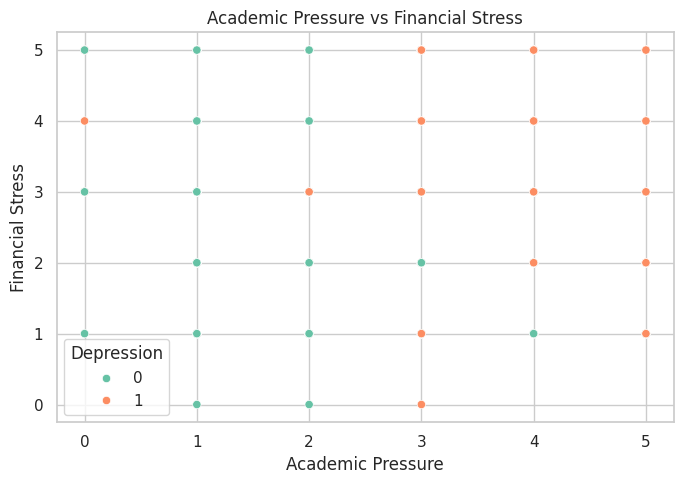

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pdf = df.select("Academic Pressure", "Financial Stress", "Depression").dropna().toPandas()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=pdf, x='Academic Pressure', y='Financial Stress', hue='Depression', palette='Set2')
plt.title('Academic Pressure vs Financial Stress')
plt.xlabel('Academic Pressure')
plt.ylabel('Financial Stress')
plt.tight_layout()
plt.show()


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import warnings
warnings.filterwarnings(
    "ignore",
    message="datetime.datetime.utcnow() is deprecated",
    category=DeprecationWarning,
    module="jupyter_client.session"
)

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import warnings
warnings.filterwarnings(
    "ignore",
    message="datetime.datetime.utcnow() is deprecated",
    category=DeprecationWarning,
    module="jupyter_client.session"
)

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from pyspark.sql.functions import col, when
from IPython.display import display, HTML

df_selected_spark = df.select(
    'Academic Pressure', 'CGPA', 'Sleep Duration', 'Financial Stress', 'Depression'
).na.drop()

df_bin_spark = (
    df_selected_spark
    .withColumn('High_CGPA', when(col('CGPA') > 3.0, 1).otherwise(0))
    .withColumn('High_Stress', when(col('Financial Stress') > 3, 1).otherwise(0))
    .withColumn('High_Pressure', when(col('Academic Pressure') > 3, 1).otherwise(0))
    .withColumn('Low_Sleep', when(col('Sleep Duration').isin('Less than 5 hours', '5-6 hours'), 1).otherwise(0))
    .withColumn('Depressed', when((col('Depression') == 'Yes') | (col('Depression') == 1), 1).otherwise(0))
)

df_bin_spark = df_bin_spark.select('High_CGPA', 'High_Stress', 'High_Pressure', 'Low_Sleep', 'Depressed')

df_bin_pandas = df_bin_spark.toPandas().astype(int)

df_sample = df_bin_pandas.sample(frac=0.3, random_state=42)

freq_apriori = apriori(df_sample, min_support=0.2, use_colnames=True)

rules_apriori = association_rules(freq_apriori, metric='confidence', min_threshold=0.6)

rules_apriori = (
    rules_apriori[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
    .sort_values(by='lift', ascending=False)
    .reset_index(drop=True)
)

rules_apriori['antecedents'] = rules_apriori['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_apriori['consequents'] = rules_apriori['consequents'].apply(lambda x: ', '.join(list(x)))

print("=== BẢNG LUẬT KẾT HỢP (APRIORI) ===")
display(
    HTML(
        rules_apriori.style
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([{
            'selector': 'th',
            'props': [('background-color', '#2E86C1'),
                      ('color', 'white'),
                      ('text-align', 'center')]
        }])
        .bar(subset=['support', 'confidence', 'lift'], color='#85C1E9')
        .hide(axis="index")
        .to_html()
    )
)

rules_depression = rules_apriori[rules_apriori['consequents'].str.contains('Depressed', case=False, na=False)]

print("\n===  LUẬT DỰ ĐOÁN TRẦM CẢM (Depressed) ===")
display(
    HTML(
        rules_depression.style
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([{
            'selector': 'th',
            'props': [('background-color', '#27AE60'),
                      ('color', 'white'),
                      ('text-align', 'center')]
        }])
        .bar(subset=['support', 'confidence', 'lift'], color='#82E0AA')
        .hide(axis="index")
        .to_html()
    )
)

=== BẢNG LUẬT KẾT HỢP (APRIORI) ===


antecedents,consequents,support,confidence,lift
High_Pressure,"High_CGPA, Depressed",0.335245,0.814750,1.406074
"High_Pressure, High_CGPA",Depressed,0.335245,0.814750,1.406074
High_Pressure,Depressed,0.335245,0.814750,1.406074
"High_Stress, High_CGPA",Depressed,0.337395,0.756294,1.305191
High_Stress,Depressed,0.337395,0.756091,1.304842
High_Stress,"High_CGPA, Depressed",0.337395,0.756091,1.304842
"High_CGPA, Low_Sleep",Depressed,0.325687,0.618141,1.066770
Low_Sleep,"High_CGPA, Depressed",0.325687,0.618000,1.066529
Low_Sleep,Depressed,0.325687,0.618000,1.066529
High_Pressure,High_CGPA,0.411470,1.000000,1.000359



===  LUẬT DỰ ĐOÁN TRẦM CẢM (Depressed) ===


antecedents,consequents,support,confidence,lift
High_Pressure,"High_CGPA, Depressed",0.335245,0.814750,1.406074
"High_Pressure, High_CGPA",Depressed,0.335245,0.814750,1.406074
High_Pressure,Depressed,0.335245,0.814750,1.406074
"High_Stress, High_CGPA",Depressed,0.337395,0.756294,1.305191
High_Stress,Depressed,0.337395,0.756091,1.304842
High_Stress,"High_CGPA, Depressed",0.337395,0.756091,1.304842
"High_CGPA, Low_Sleep",Depressed,0.325687,0.618141,1.066770
Low_Sleep,"High_CGPA, Depressed",0.325687,0.618000,1.066529
Low_Sleep,Depressed,0.325687,0.618000,1.066529


In [ ]:
df.coalesce(1) \
  .write.csv(
      "file:///content/student_depression_csv",
      header=True,
      mode="overwrite"
  )